In [ ]:
import matplotlib.pyplot as plt
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_data_directory = '/content/drive/MyDrive/train'

In [ ]:
test_data_directory = '/content/drive/MyDrive/test'

In [ ]:
pic1 = cv2.imread('/content/drive/MyDrive/train/chickens/01I4JR8PX3B8.jpg')
pic1 = cv2.cvtColor(pic1, cv2.COLOR_BGR2RGB)

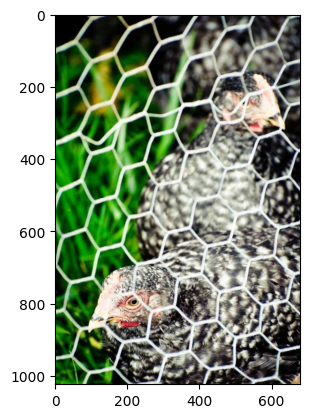

In [ ]:
plt.imshow(pic1)

In [ ]:
pic1.shape

(1024, 678, 3)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Tăng cường dữ liệu ảnh

- **Xoay ảnh ngẫu nhiên** trong khoảng từ **-30 đến 30 độ** nhằm giúp mô hình học được sự biến thiên về góc chụp.
- **Dịch ảnh theo chiều ngang** tối đa **10%** tổng chiều rộng ảnh và **dịch theo chiều dọc** tối đa **10%** tổng chiều cao ảnh để tạo sự đa dạng về vị trí đối tượng.
- **Chuẩn hóa pixel**: Tất cả giá trị pixel được chia cho **255** để đưa về khoảng **[0, 1]**.
- **Biến dạng xiên (shear transformation)** với góc **0.2 radian (~11.5 độ)** để làm thay đổi hình dạng đối tượng theo phương xiên.
- **Phóng to hoặc thu nhỏ ảnh** trong khoảng **±20%** giúp mô hình học được sự thay đổi về tỷ lệ kích thước của đối tượng.
- **Lật ngang ảnh ngẫu nhiên** để mô hình làm quen với hình ảnh phản chiếu, tăng khả năng tổng quát hóa.
- **Lấp đầy vùng trống** (sinh ra do xoay, dịch chuyển, thu phóng...) bằng **giá trị pixel gần nhất** nhằm tránh nhiễu từ các giá trị không xác định.


In [ ]:
image_gen = ImageDataGenerator(rotation_range=30,
                              width_shift_range=0.1,
                              height_shift_range=0.1,
                              rescale=1/255,
                              shear_range=0.2,
                              zoom_range=0.2,
                              horizontal_flip=True,
                              fill_mode='nearest')

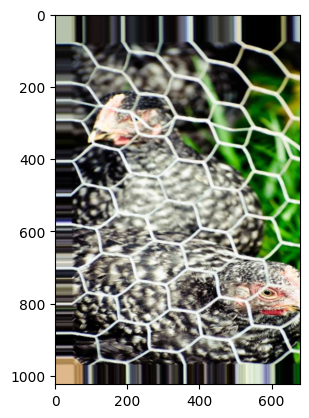

In [ ]:
plt.imshow(image_gen.random_transform(pic1))

In [ ]:
image_gen.flow_from_directory(train_data_directory)

Found 1319 images belonging to 4 classes.


In [ ]:
from keras.models import Sequential

In [ ]:
from keras.layers import Activation, Dropout, Flatten, Conv2D, MaxPooling2D, Dense

In [ ]:
input_shape=(224,224,3)

In [ ]:
# Số lớp cần phân loại (4 lớp: chó, mèo, lợn, gà)
num_classes = 4

model = Sequential()


model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=(224,224,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))


model.compile(
    loss='categorical_crossentropy',  # Dùng cho one-hot encoded labels
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 43264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       5,537,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,594,756 (21.34 MB)

 Trainable params: 5,594,756 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_generator = image_gen.flow_from_directory(
    train_data_directory,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical' )

Found 1319 images belonging to 4 classes.


In [ ]:
train_generator.class_indices

{'cats': 0, 'chickens': 1, 'dogs': 2, 'pigs': 3}

In [ ]:
batch_size=32

In [ ]:
test_generator = image_gen.flow_from_directory(
    test_data_directory,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 200 images belonging to 4 classes.


In [ ]:
results = model.fit(train_generator, epochs=10, steps_per_epoch =len(train_generator),
                             validation_data=test_generator,validation_steps=len(test_generator))

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3341 - loss: 1.3014

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


42/42 ━━━━━━━━━━━━━━━━━━━━ 496s 12s/step - accuracy: 0.3352 - loss: 1.3010 - val_accuracy: 0.3950 - val_loss: 1.2002
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 45s 953ms/step - accuracy: 0.4565 - loss: 1.2117 - val_accuracy: 0.4450 - val_loss: 1.2071
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 968ms/step - accuracy: 0.4622 - loss: 1.2046 - val_accuracy: 0.4200 - val_loss: 1.1882
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 952ms/step - accuracy: 0.4602 - loss: 1.2245 - val_accuracy: 0.4100 - val_loss: 1.1371
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 965ms/step - accuracy: 0.4934 - loss: 1.0995 - val_accuracy: 0.5050 - val_loss: 1.1071
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 974ms/step - accuracy: 0.5362 - loss: 1.0951 - val_accuracy: 0.4950 - val_loss: 1.0986
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5356 - loss: 1.0682 - val_accuracy: 0.5000 - val_loss: 1.0866
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 988ms/step - accuracy: 0.5582 - loss: 1.0961 - val_accuracy: 0.5200 - 

In [ ]:
history = model.fit(
    train_generator,
    epochs=50,  # Tổng epochs mong muốn (10 + 40)
    initial_epoch=10,  # Bắt đầu từ epoch 11
    steps_per_epoch=len(train_generator),
    validation_data=test_generator,
    validation_steps=len(test_generator))

Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.5932 - loss: 0.9891 - val_accuracy: 0.5700 - val_loss: 1.0333
Epoch 12/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5995 - loss: 0.9432 - val_accuracy: 0.5350 - val_loss: 1.0893
Epoch 13/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 79s 960ms/step - accuracy: 0.5825 - loss: 1.0049 - val_accuracy: 0.5200 - val_loss: 1.0209
Epoch 14/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 956ms/step - accuracy: 0.6078 - loss: 0.9595 - val_accuracy: 0.5250 - val_loss: 1.0576
Epoch 15/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 922ms/step - accuracy: 0.6126 - loss: 0.9417 - val_accuracy: 0.5550 - val_loss: 1.0294
Epoch 16/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 939ms/step - accuracy: 0.6358 - loss: 0.9440 - val_accuracy: 0.5500 - val_loss: 1.0233
Epoch 17/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 929ms/step - accuracy: 0.5964 - loss: 0.9458 - val_accuracy: 0.6150 - val_loss: 0.9058
Epoch 18/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 943ms/step - accuracy: 0.6388 - loss: 0.8916 - val_ac

In [ ]:
model.save('model1.keras')  # Tạo thư mục chứa các file .pb và assets

# Check model 1

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/model_hocSau/model1.keras')

In [ ]:
# Đánh giá trên tập test (test_generator hoặc X_test, y_test)
test_loss, test_accuracy = model.evaluate(
    test_generator,  # Hoặc (X_test, y_test) nếu dùng dữ liệu numpy
    steps=len(test_generator)  # Bắt buộc nếu dùng generator
)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 79s 11s/step - accuracy: 0.6674 - loss: 0.8833
Test Loss: 0.9408
Test Accuracy: 0.6900


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Dự đoán trên tập test
y_pred = model.predict(test_generator, steps=len(test_generator))
y_pred_classes = np.argmax(y_pred, axis=1)  # Chuyển sang lớp dự đoán (nếu phân loại nhiều lớp)

# Lấy nhãn thực tế (nếu dùng generator)
y_true = test_generator.classes  # Hoặc y_test nếu dùng dữ liệu numpy

# Tính các metrics
print(classification_report(y_true, y_pred_classes))
print(confusion_matrix(y_true, y_pred_classes))

7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step
              precision    recall  f1-score   support

           0       0.26      0.30      0.28        50
           1       0.26      0.26      0.26        50
           2       0.31      0.28      0.29        50
           3       0.27      0.26      0.27        50

    accuracy                           0.28       200
   macro avg       0.28      0.28      0.28       200
weighted avg       0.28      0.28      0.28       200

[[15 10 12 13]
 [13 13 12 12]
 [13 13 14 10]
 [16 14  7 13]]


# Layers model 1

In [ ]:
from tensorflow.keras.utils import plot_model

In [ ]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Conv2D name=conv2d_2, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [ ]:
for layer in model.layers:
    print(f"Tên lớp: {layer.name}")
    print(f"Loại lớp: {layer.__class__.__name__}")
    print(f"Số tham số trainable: {layer.count_params()}")
    print("-" * 40)


Tên lớp: conv2d
Loại lớp: Conv2D
Số tham số trainable: 896
----------------------------------------
Tên lớp: max_pooling2d
Loại lớp: MaxPooling2D
Số tham số trainable: 0
----------------------------------------
Tên lớp: conv2d_1
Loại lớp: Conv2D
Số tham số trainable: 18496
----------------------------------------
Tên lớp: max_pooling2d_1
Loại lớp: MaxPooling2D
Số tham số trainable: 0
----------------------------------------
Tên lớp: conv2d_2
Loại lớp: Conv2D
Số tham số trainable: 36928
----------------------------------------
Tên lớp: max_pooling2d_2
Loại lớp: MaxPooling2D
Số tham số trainable: 0
----------------------------------------
Tên lớp: flatten
Loại lớp: Flatten
Số tham số trainable: 0
----------------------------------------
Tên lớp: dense
Loại lớp: Dense
Số tham số trainable: 5537920
----------------------------------------
Tên lớp: dropout
Loại lớp: Dropout
Số tham số trainable: 0
----------------------------------------
Tên lớp: dense_1
Loại lớp: Dense
Số tham số trainable

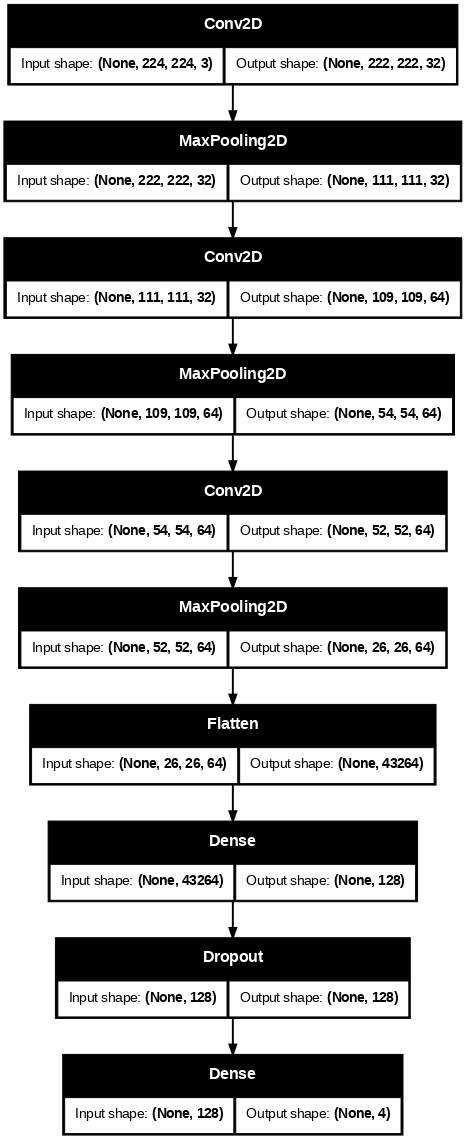

In [ ]:
plot_model(model, show_shapes=True, dpi=70)


# Giải thích model 1


## Tổng quan kiến trúc
Mô hình sử dụng kiến trúc CNN (Convolutional Neural Network) tuần tự với:
- **3 khối Convolution-Pooling** để trích xuất đặc trưng
- **1 lớp Fully Connected** để phân loại
- Đầu ra **4 lớp** (tương ứng 4 loại động vật) với hàm kích hoạt `softmax`

## Chi tiết các lớp

### 1. Lớp Convolution đầu tiên
- 32 filters (bộ lọc) để phát hiện đặc trưng cơ bản như cạnh, màu sắc

- Kích thước kernel 3x3 cho receptive field nhỏ

- Input shape 224x224x3 (ảnh màu RGB kích thước 224x224)

- Hàm kích hoạt ReLU để thêm tính phi tuyến

### 2. Lớp Max Pooling đầu tiên
- Giảm chiều dữ liệu bằng cách lấy giá trị lớn nhất trong vùng 2x2

- Giúp mô hình ít nhạy cảm với vị trí đặc trưng và giảm tính toán.

### 3. Các lớp Convolution-Pooling tiếp theo
- Tăng dần số filters lên 64 để học đặc trưng phức tạp hơn

- Tiếp tục sử dụng kernel 3x3 và pooling 2x2

### 4. Lớp Flatten
- Chuyển đổi dữ liệu từ tensor 3D sang vector 1D để chuẩn bị cho lớp Dense

### 5. Lớp Fully Connected
- 128 neurons để học mối quan hệ phức tạp giữa các đặc trưng

- Tiếp tục dùng ReLU làm hàm kích hoạt

### 6. Lớp Dropout

- Tỉ lệ 0.5 (50%) để ngẫu nhiên loại bỏ neurons trong quá trình huấn luyện

- Giúp chống overfitting bằng cách ngăn mô hình phụ thuộc quá vào một số đặc trưng cụ thể

### 7. Lớp đầu ra

- 4 neurons tương ứng 4 lớp cần phân loại

- Hàm softmax để chuyển đầu ra thành xác suất phân phối cho các lớp

# Phân tích kết quả phân loại đa lớp

## Classification Report

| Metric     | Class 0 | Class 1 | Class 2 | Class 3 | Accuracy | Macro Avg | Weighted Avg |
|------------|---------|---------|---------|---------|----------|-----------|--------------|
| Precision  | 0.26    | 0.26    | 0.31    | 0.27    | 0.28     | 0.28      | 0.28         |
| Recall     | 0.30    | 0.26    | 0.28    | 0.26    | -        | 0.28      | 0.28         |
| F1-score   | 0.28    | 0.26    | 0.29    | 0.27    | -        | 0.28      | 0.28         |
| Support    | 50      | 50      | 50      | 50      | 200      | 200       | 200          |

### Giải thích:
- **Precision**: Tỷ lệ dự đoán đúng trong các mẫu được dự đoán là lớp X
  - Ví dụ: Precision lớp 0 = 0.26 → 26% dự đoán lớp 0 là chính xác
- **Recall**: Tỷ lệ mẫu lớp X được dự đoán đúng
  - Ví dụ: Recall lớp 0 = 0.30 → 30% mẫu lớp 0 thực tế được nhận diện đúng
- **F1-score**: Trung bình điều hòa của Precision và Recall
- **Accuracy**: 28% - Thấp hơn nhiều so với tỷ lệ đoán ngẫu nhiên (25% cho 4 lớp)

## Đánh giá hiệu suất

- **Hiệu suất tổng thể thấp** (Accuracy = 28%)
- **Model gần như không phân biệt được** giữa các lớp
- **Nguyên nhân có thể**:
  1. Dữ liệu huấn luyện không đủ
  2. Model quá đơn giản
  3. Vấn đề tiền xử lý dữ liệu
  4. Lớp không cân bằng


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def preprocess_image(img_path, target_size=(224, 224)):
    # Load ảnh và đổi kích thước
    img = image.load_img(img_path, target_size=target_size)

    # Chuyển ảnh thành mảng numpy
    img_array = image.img_to_array(img)

    # Thêm chiều batch (vì model.predict() yêu cầu đầu vào 4D)
    img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 150, 150, 3)

    # Chuẩn hóa pixel (nếu bạn đã làm khi huấn luyện)
    img_array = img_array / 255.0  # Ví dụ: chia cho 255

    return img_array

# Ví dụ dùng ảnh mới
img_path = '/content/drive/MyDrive/test/pigs/Lon_11.jpg'
processed_img = preprocess_image(img_path)

In [ ]:
# Dự đoán
prediction = model.predict(processed_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [ ]:
class_index = np.argmax(prediction)
class_labels = ['Cat', 'Chicken', 'Dog', 'Pig']  # Thay bằng danh sách lớp của bạn
confidence = np.max(prediction)
print(f'Predicted: {class_labels[class_index]} (Confidence: {confidence:.2%})')

Predicted: Pig (Confidence: 87.16%)


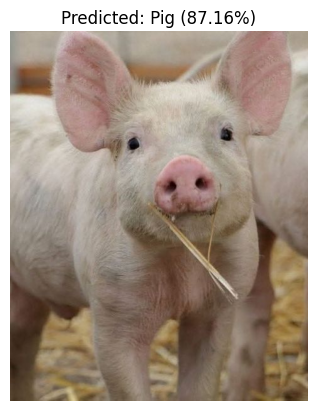

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image.load_img(img_path))
plt.title(f'Predicted: {class_labels[class_index]} ({confidence:.2%})')
plt.axis('off')
plt.show()

## Sử dụng mô hình phức tạp hơn

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% dữ liệu làm validation
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1057 images belonging to 4 classes.
Found 262 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Load EfficientNetB0 (phiên bản nhẹ nhất)
base_model = EfficientNetB0(
    include_top=False,  # Không bao gồm layer cuối
    weights='imagenet',  # Pretrained trên ImageNet
    input_shape=(224, 224, 3)
)

# Đóng băng các layer đầu (transfer learning)
base_model.trainable = False

# Thêm layer custom cho bài toán của bạn
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')  # 4 lớp đầu ra
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3),
        tf.keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
    ]
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 819ms/step - accuracy: 0.2560 - loss: 1.3848 - val_accuracy: 0.2786 - val_loss: 1.3854
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 654ms/step - accuracy: 0.2574 - loss: 1.3879 - val_accuracy: 0.2786 - val_loss: 1.3853
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 691ms/step - accuracy: 0.2931 - loss: 1.3843 - val_accuracy: 0.2786 - val_loss: 1.3850
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 700ms/step - accuracy: 0.2723 - loss: 1.3856 - val_accuracy: 0.2786 - val_loss: 1.3850
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 683ms/step - accuracy: 0.2708 - loss: 1.3854 - val_accuracy: 0.2786 - val_loss: 1.3849
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 656ms/step - accuracy: 0.2740 - loss: 1.3850 - val_accuracy: 0.2786 - val_loss: 1.3849
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 694ms/step - accuracy: 0.2834 - loss: 1.3849 - val_accuracy: 0.2786 - val_loss: 1.3846
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 28s 839ms/step - accuracy: 0.3010 - loss: 1.3831 - 

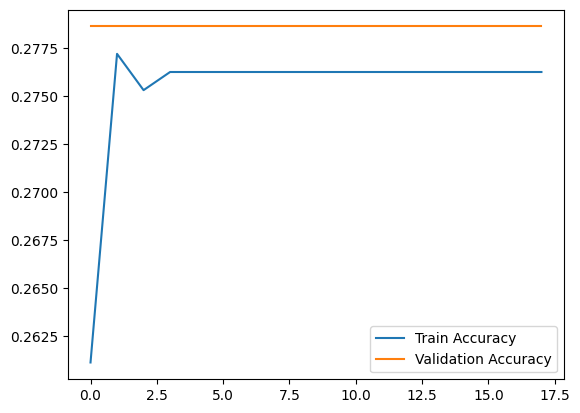

In [ ]:
import matplotlib.pyplot as plt

# Vẽ đồ thị accuracy và loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

## Failed

# EfficientnetV2_L


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras import layers, models, optimizers, callbacks

# 1. Khởi tạo base model
base_model = EfficientNetV2L(
    include_top=False,
    weights='imagenet',
    input_shape=(480, 480, 3),
    pooling='avg'
)
base_model.trainable = False


inputs = layers.Input(shape=(480, 480, 3))
x = base_model(inputs, training=False)

# Các lớp FC
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs, outputs)

# 4. Compile với learning rate schedule
initial_lr = 1e-3
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_lr,
    decay_steps=10000,
    decay_rate=0.9
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             'Precision',
             'Recall']
)

# 5. Callbacks
callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )
]

# 6. Model summary
model.summary()

# 7. Kiểm tra forward pass
try:
    dummy_input = tf.random.normal((1, 480, 480, 3))
    output = model(dummy_input)
    print("\nForward pass successful! Output shape:", output.shape)
except Exception as e:
    print("\nError in forward pass:", e)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 480, 480, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-l (Functional)   │ (None, 1280)           │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,538,148 (452.19 MB)

 Trainable params: 789,764 (3.01 MB)

 Non-trainable params: 117,748,384 (449.17 MB)


Forward pass successful! Output shape: (1, 4)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% dữ liệu làm validation
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',  # Thay bằng path của bạn
    target_size=(480, 480),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',
    target_size=(480, 480),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1057 images belonging to 4 classes.
Found 262 images belonging to 4 classes.


In [ ]:
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3),
        tf.keras.callbacks.ModelCheckpoint('efficientV2_L.keras', save_best_only=True)
    ]
)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 523s 12s/step - accuracy: 0.2300 - loss: 1.4166 - val_accuracy: 0.3168 - val_loss: 1.3853
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.2754 - loss: 1.3866 - val_accuracy: 0.2786 - val_loss: 1.3842
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.2536 - loss: 1.3992 - val_accuracy: 0.2786 - val_loss: 1.3844
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.2788 - loss: 1.3856 - val_accuracy: 0.2786 - val_loss: 1.3865
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.2464 - loss: 1.3999 - val_accuracy: 0.2901 - val_loss: 1.3794
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.2467 - loss: 1.3877 - val_accuracy: 0.2786 - val_loss: 1.3773
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.2806 - loss: 1.3839 - val_accuracy: 0.3817 - val_loss: 1.3768
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 0.2556 - loss: 1.3827 - val_accuracy: 0.3550 - 

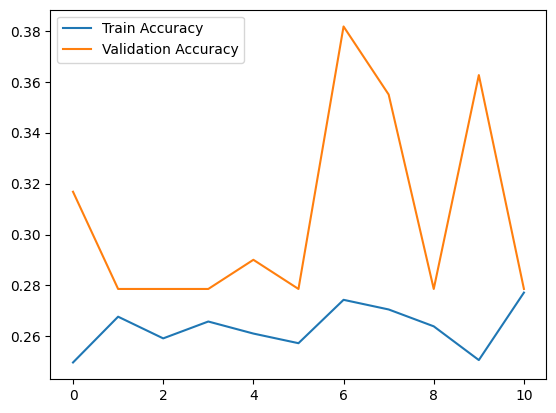

In [ ]:
import matplotlib.pyplot as plt

# Vẽ đồ thị accuracy và loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

## Fail

# Again

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,      # Rescale pixel values to [0, 1]
    rotation_range=25,      # Randomly rotate images by up to 25 degrees
    width_shift_range=0.3,  # Randomly shift the width of images
    height_shift_range=0.3, # Randomly shift the height of images
    horizontal_flip=True,   # Randomly flip images horizontally
    shear_range=0.3,        # Apply shear transformations
    zoom_range=0.4,         # Randomly zoom into images
    fill_mode='nearest',     # Fill empty pixels with the nearest value
    validation_split=0.2  # 20% dữ liệu làm validation
)

test_datagen = ImageDataGenerator(rescale = 1.0 / 255)
# Create data generators for training and validation data
batch_size = 32
image_size = (480,480)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/test',
    target_size=image_size,
    shuffle=False,
    class_mode='categorical',
    batch_size=1
)

Found 1057 images belonging to 4 classes.
Found 262 images belonging to 4 classes.
Found 200 images belonging to 4 classes.


In [ ]:
early_stopping = keras.callbacks.EarlyStopping( monitor='val_accuracy',patience=5,restore_best_weights=True)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
import tensorflow_hub as hub

import os
import random
import shutil
from math import ceil, sqrt

In [ ]:
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

# 1. Input
inputs = Input(shape=(480, 480, 3))

# 2. EfficientNetV2L từ keras, không cần tải từ TFHub
base_model = EfficientNetV2L(include_top=False, input_tensor=inputs, pooling='avg', weights='imagenet')
base_model.trainable = False  # Freeze

# 3. Fully-connected layers
x = Dense(512, activation='relu')(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(4, activation='softmax')(x)

# 4. Compile model
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 480, 480,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 480, 480,  │          0 │ input_layer_11[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 240, 240,  │        864 │ rescaling_3[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 240, 240,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 240, 240,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 240, 240,  │      9,216 │ stem_activation[… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 240, 240,  │        128 │ block1a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 240, 240,  │          0 │ block1a_project_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 240, 240,  │          0 │ block1a_project_… │
│                     │ 32)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 240, 240,  │      9,216 │ block1a_add[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 240, 240,  │        128 │ block1b_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 240, 240,  │          0 │ block1b_project_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 240, 240,  │          0 │ block1b_project_… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 240, 240,  │          0 │ block1b_drop[0][… │
│                     │ 32)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_co… │ (None, 240, 240,  │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_bn  │ (None, 240, 240,  │        128 │ block1c_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_ac… │ (None, 240, 240,  │          0 │ block1c_project_

 Total params: 118,538,148 (452.19 MB)

 Trainable params: 789,764 (3.01 MB)

 Non-trainable params: 117,748,384 (449.17 MB)

In [ ]:
history = model.fit(train_generator, epochs=50, validation_data=val_generator, callbacks=[early_stopping])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 279s 5s/step - accuracy: 0.2562 - loss: 2.1526 - val_accuracy: 0.2443 - val_loss: 1.3905
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.2542 - loss: 1.8053 - val_accuracy: 0.2366 - val_loss: 1.3848
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.2695 - loss: 1.7554 - val_accuracy: 0.2405 - val_loss: 1.4287
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.2399 - loss: 1.7438 - val_accuracy: 0.3511 - val_loss: 1.3761
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.2851 - loss: 1.6036 - val_accuracy: 0.3092 - val_loss: 1.3740
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.2976 - loss: 1.6028 - val_accuracy: 0.3473 - val_loss: 1.3622
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.2576 - loss: 1.6319 - val_accuracy: 0.3321 - val_loss: 1.3680
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.2857 - loss: 1.5832 - val_accuracy: 0.2672 - v

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Thiết lập data generators với augmentation và preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',  # Thay bằng path của bạn
    target_size=(480, 480),  # Khớp với input_shape của EfficientNetV2L
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',
    target_size=(480, 480),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 2. Khởi tạo base model
base_model = EfficientNetV2L(
    include_top=False,
    weights='imagenet',  # Pretrained trên ImageNet-21k
    input_shape=(480, 480, 3),
    pooling='avg'  # Tự động thêm GlobalAveragePooling2D
)
base_model.trainable = False  # Đóng băng các layer

# 3. Xây dựng model
inputs = layers.Input(shape=(480, 480, 3))
x = base_model(inputs, training=False)  # Quan trọng: training=False cho BN layers

# Thêm các lớp custom
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(4, activation='softmax')(x)  # 4 lớp đầu ra

model = models.Model(inputs, outputs)

# 4. Compile model
initial_lr = 1e-3
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_lr,
    decay_steps=10000,
    decay_rate=0.9
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             'Precision',
             'Recall']
)

# 5. Callbacks
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )
]

# 6. Huấn luyện model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks_list
)

# 7. Đánh giá model
model.evaluate(val_generator)

# 8. Lưu model (tùy chọn)
model.save('efficientnetv2l_animal_classifier.keras')

Found 1057 images belonging to 4 classes.
Found 262 images belonging to 4 classes.
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - Precision: 0.8507 - Recall: 0.8070 - accuracy: 0.8299 - loss: 0.5096 - val_Precision: 1.0000 - val_Recall: 0.9351 - val_accuracy: 0.9962 - val_loss: 0.1738 - learning_rate: 9.9964e-04
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - Precision: 0.9954 - Recall: 0.9947 - accuracy: 0.9947 - loss: 0.0161 - val_Precision: 1.0000 - val_Recall: 0.9809 - val_accuracy: 0.9962 - val_loss: 0.1056 - learning_rate: 9.9928e-04
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - Precision: 0.9804 - Recall: 0.9776 - accuracy: 0.9798 - loss: 0.0565 - val_Precision: 1.0000 - val_Recall: 0.9924 - val_accuracy: 0.9962 - val_loss: 0.0702 - learning_rate: 9.9893e-04
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - Precision: 0.9983 - Recall: 0.9968 - accuracy: 0.9983 - loss: 0.0204 - val_Precision: 0.9962 - val_Recall: 0.9885 - val_accuracy: 0.9962 - val_loss: 0.05

In [ ]:
model.save('efficientnetv2l_animal_classifier.keras')

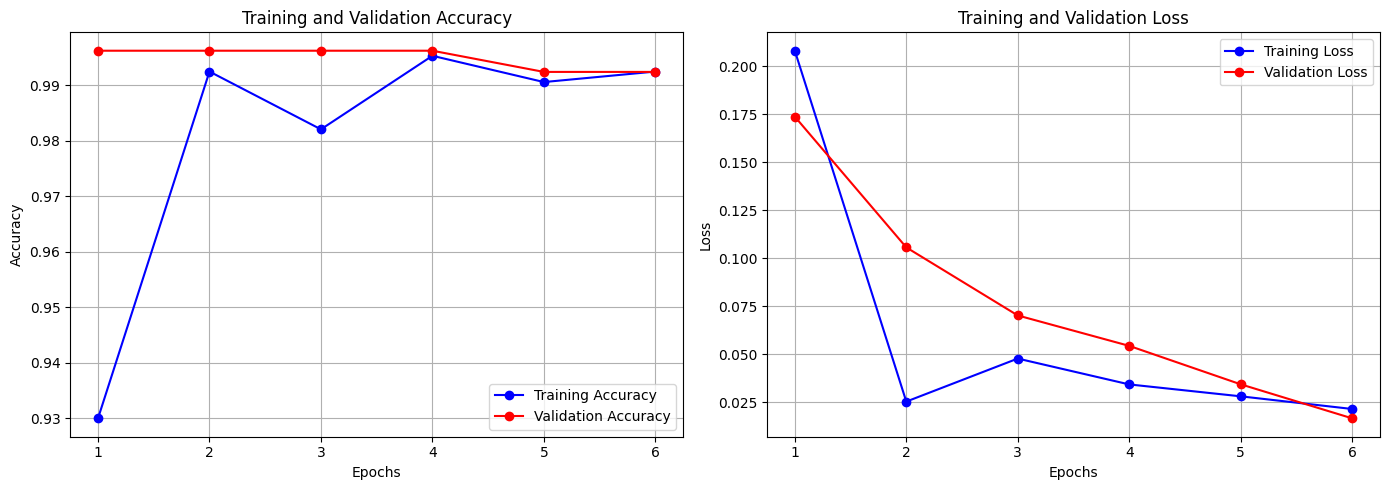

In [ ]:
import matplotlib.pyplot as plt

# Lấy history từ quá trình training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Tạo figure với 2 subplots
plt.figure(figsize=(14, 5))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step
Classification Report:
              precision    recall  f1-score   support

        cats       0.27      0.27      0.27        64
    chickens       0.26      0.26      0.26        73
        dogs       0.26      0.26      0.26        62
        pigs       0.27      0.27      0.27        63

    accuracy                           0.26       262
   macro avg       0.26      0.26      0.26       262
weighted avg       0.26      0.26      0.26       262



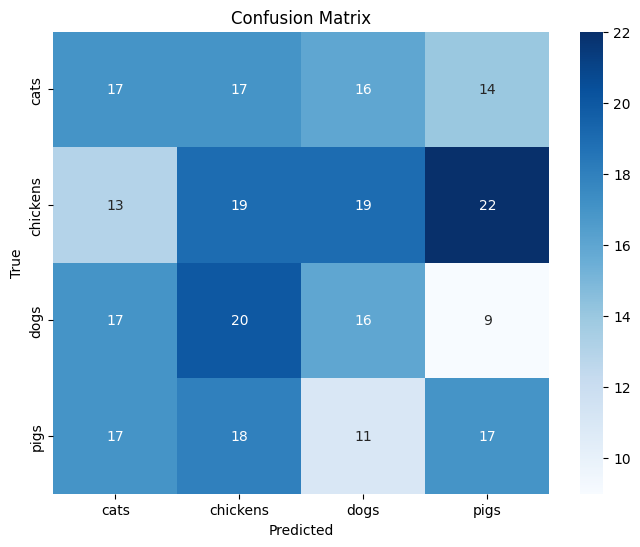

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Dự đoán trên tập validation
val_preds = model.predict(val_generator)
val_pred_classes = np.argmax(val_preds, axis=1)

# Lấy true labels
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Classification report
print("Classification Report:")
print(classification_report(true_classes, val_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(true_classes, val_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#  1. Giải thích Classification Report

### Precision:
- Xác suất dự đoán đúng khi mô hình dự đoán một ảnh thuộc lớp đó.
- `precision = 0.27` cho **cats** nghĩa là chỉ có 27% số ảnh mà mô hình dự đoán là "cats" là đúng.

### Recall:
- Tỷ lệ ảnh đúng thuộc lớp đó mà mô hình thực sự nhận diện đúng.
- `recall = 0.26` cho **dogs** nghĩa là mô hình chỉ đúng với 26% trong tổng số ảnh "dogs" thật sự.

### F1-score:
- Trung bình điều hòa giữa Precision và Recall.
- Thể hiện sự cân bằng giữa việc không bỏ sót và không đoán sai.

---

## 2. Kết quả tổng thể:

| Loại        | Giá trị  | Ý nghĩa |
|-------------|----------|---------|
| **Accuracy**| 0.26     | Tỷ lệ dự đoán đúng trên toàn bộ tập kiểm tra (26%). |
| **Macro avg** | 0.26   | Trung bình cộng của precision/recall/f1-score trên các lớp, không quan tâm số mẫu mỗi lớp. |
| **Weighted avg** | 0.26 | Trung bình có trọng số theo số mẫu (support) của mỗi lớp. |

---

## 3. Kết luận:

- **Hiệu suất mô hình còn rất thấp (~26%)**, cho thấy mô hình chưa học được đặc trưng tốt để phân biệt các lớp "chó, mèo, lợn, gà".
- Precision/Recall đều thấp và gần bằng nhau → mô hình đang đoán ngẫu nhiên ,underfitting.



In [ ]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 480, 480, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-l (Functional)   │ (None, 1280)           │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,117,677 (458.21 MB)

 Trainable params: 789,764 (3.01 MB)

 Non-trainable params: 117,748,384 (449.17 MB)

 Optimizer params: 1,579,529 (6.03 MB)

In [ ]:
results = model.evaluate(test_generator)
print(results)



200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.0359 - loss: 1.4766
[1.3922027349472046, 0.25, 0.0, 0.0]


In [ ]:
print(train_generator.class_indices)
print(test_generator.class_indices)


{'cats': 0, 'chickens': 1, 'dogs': 2, 'pigs': 3}
{'cats': 0, 'chickens': 1, 'dogs': 2, 'pigs': 3}


In [ ]:
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)


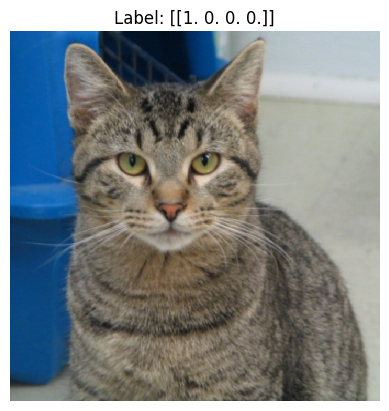

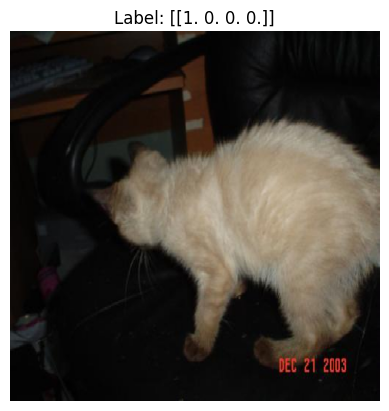

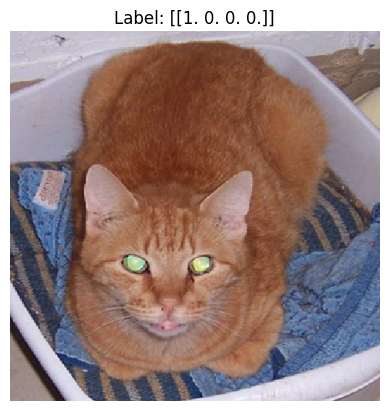

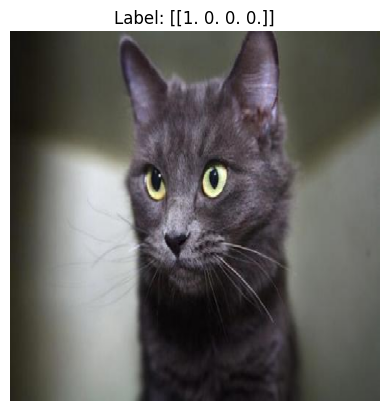

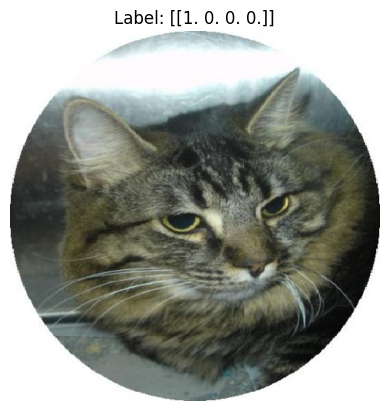

In [ ]:
import matplotlib.pyplot as plt

for i in range(5):
    img, label = test_generator[i]
    plt.imshow(img[0])
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()


In [ ]:
results = model.evaluate(test_generator)
print(results)




200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.0359 - loss: 1.4766
[1.3922027349472046, 0.25, 0.0, 0.0]


# 27/4/2025

In [ ]:

import tensorflow as tf
from tensorflow import keras


from tensorflow.keras.applications import EfficientNetV2L  # Pretrained model
from tensorflow.keras import layers  # Các lớp neural network (Dense, Conv2D,...)
from tensorflow.keras import models  # Để tạo Sequential/Functional API models
from tensorflow.keras import optimizers  # Optimizer (Adam, SGD,...)
from tensorflow.keras import callbacks  # Callbacks (EarlyStopping, ModelCheckpoint,...)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from tensorflow.keras.metrics import Precision, Recall  # Đánh giá độ chính xác, recall

import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/test',
    target_size=(480, 480),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

Found 200 images belonging to 4 classes.


In [ ]:
images, labels = next(test_generator)

print("Shape của batch ảnh:", images.shape)
print("Shape của label:", labels.shape)

print("\nShape ảnh đầu tiên:", images[0].shape)
print("Giá trị pixel (vài pixel đầu):", images[0][0][:5])  # In 5 pixel đầu dòng đầu tiên
print("Min pixel:", images[0].min())
print("Max pixel:", images[0].max())

Shape của batch ảnh: (32, 480, 480, 3)
Shape của label: (32, 4)

Shape ảnh đầu tiên: (480, 480, 3)
Giá trị pixel (vài pixel đầu): [[ 10.  84. 157.]
 [ 11.  85. 158.]
 [ 11.  85. 160.]
 [ 10.  84. 159.]
 [  7.  83. 158.]]
Min pixel: 0.0
Max pixel: 233.0


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Thiết lập data generators với augmentation và preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',
    target_size=(480, 480),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/train',
    target_size=(480, 480),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 2. Khởi tạo base model
base_model = EfficientNetV2L(
    include_top=False,
    weights='imagenet',
    input_shape=(480, 480, 3),
    pooling='avg'
)
base_model.trainable = False  # Freeze ban đầu

# 3. Xây dựng model
inputs = layers.Input(shape=(480, 480, 3))
x = base_model(inputs, training=False)

x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs, outputs)

# 4. Compile model
initial_lr = 1e-3
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_lr,
    decay_steps=5000,
    decay_rate=0.9
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# 5. Callbacks
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

# 6. Huấn luyện model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks_list
)

# 7. Fine-tune nhẹ (unfreeze 30% cuối)
base_model.trainable = True
for layer in base_model.layers[:int(0.7 * len(base_model.layers))]:
    layer.trainable = False


model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# 8. Huấn luyện fine-tune
history_finetune = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks_list
)

# 9. Đánh giá model
model.evaluate(val_generator)



Found 1057 images belonging to 4 classes.
Found 262 images belonging to 4 classes.
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 283s 5s/step - accuracy: 0.8005 - loss: 0.5850 - precision_1: 0.8250 - recall_1: 0.7871 - val_accuracy: 0.9885 - val_loss: 0.2008 - val_precision_1: 1.0000 - val_recall_1: 0.9275
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.9860 - loss: 0.0487 - precision_1: 0.9885 - recall_1: 0.9854 - val_accuracy: 0.9924 - val_loss: 0.1081 - val_precision_1: 1.0000 - val_recall_1: 0.9733
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - accuracy: 0.9760 - loss: 0.0498 - precision_1: 0.9797 - recall_1: 0.9760 - val_accuracy: 0.9924 - val_loss: 0.0685 - val_precision_1: 0.9922 - val_recall_1: 0.9733
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.9776 - loss: 0.0751 - precision_1: 0.9780 - recall_1: 0.9768 - val_accuracy: 0.9924 - val_loss: 0.0448 - val_precision_1: 0.9962 - val_recall_1: 0.9885
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/ste

[0.010867207311093807,
 0.9923664331436157,
 0.9961685538291931,
 0.9923664331436157]

# Huấn luyện mô hình phân loại ảnh sử dụng EfficientNetV2L

---

## 1. Chuẩn bị dữ liệu với ImageDataGenerator
  - Augmentation: Làm đa dạng dữ liệu bằng cách xoay, dịch, zoom, điều chỉnh độ sáng...

  - preprocessing_function=preprocess_input: Dùng preprocessing tương thích với EfficientNetV2L. (Đổi các pixel về float)

  - validation_split=0.2: Tự động tách 20% dữ liệu để làm tập validation.

  - flow_from_directory(...): Nạp ảnh từ thư mục và gắn nhãn tự động theo folder.

## 2.  Khởi tạo base model EfficientNetV2L

  - EfficientNetV2L là mạng học sâu được huấn luyện sẵn trên ImageNet, rất mạnh trong nhận dạng ảnh.

  - include_top=False: Bỏ phần fully-connected gốc, để ta tùy chỉnh phần cuối.

  - pooling='avg': Dùng GlobalAveragePooling để rút gọn đặc trưng thành vector 1D.

  - trainable = False: Đóng băng toàn bộ base model để không huấn luyện lại trong bước đầu.

## 3. Xây dựng phần đầu ra của mô hình
  x = base_model(inputs, training=False)
  
  x = Dense(512, relu) → BatchNorm → Dropout(0.5)
  
  x = Dense(256, relu) → BatchNorm → Dropout(0.3)
  
  outputs = Dense(4, softmax)

  - Thêm 2 lớp Dense để học đặc trưng riêng của dữ liệu.

  - Dùng BatchNormalization để ổn định quá trình huấn luyện.

  - Dropout giúp chống overfitting.

  - Cuối cùng là lớp Dense(4, activation='softmax') tương ứng với 4 lớp cần phân loại.

## 4. Compile mô hình
  - Dùng ExponentialDecay để giảm learning rate dần trong quá trình huấn luyện.

  - Optimizer: Adam.

  - Loss: categorical_crossentropy (do đầu ra là one-hot).

  - Metrics: accuracy, precision và recall để theo dõi chi tiết hiệu suất.

## 5.Callbacks – EarlyStopping
  - Ngưng huấn luyện sớm nếu validation loss không cải thiện sau 5 epoch.

  - restore_best_weights=True: Quay lại model tốt nhất đã lưu.

## 6. Huấn luyện mô hình giai đoạn đầu (Frozen base)

  - Huấn luyện phần đầu ra trong khi base EfficientNetV2L vẫn bị đóng băng.

  - Tăng tốc huấn luyện và tránh overfitting.

## 7. Fine-tuning (mở khóa 30% cuối của base model)
  - Mở khóa 30% cuối của EfficientNetV2L để fine-tune trên tập dữ liệu cụ thể.

  - Vẫn giữ 70% đầu của model gốc bị đóng băng.

## 8.Huấn luyện lại (fine-tune)
  - Compile lại với learning rate nhỏ hơn (1e-4) để tránh làm sai lệch weights đã học.

  - Fine-tuning giúp cải thiện khả năng nhận dạng đặc trưng riêng của dữ liệu hiện tại.

## 9. Đánh giá mô hình
  - Đánh giá final model trên tập validation.

  - Trả về các chỉ số loss, accuracy, precision và recall.




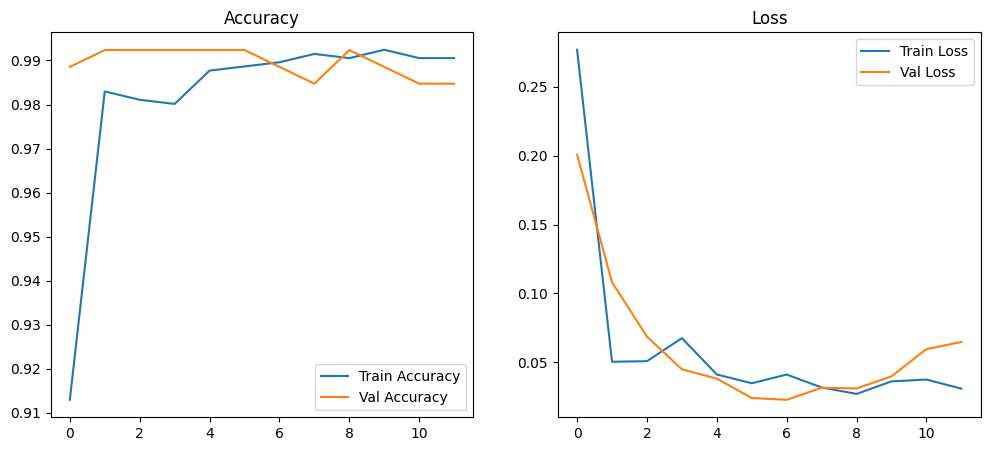

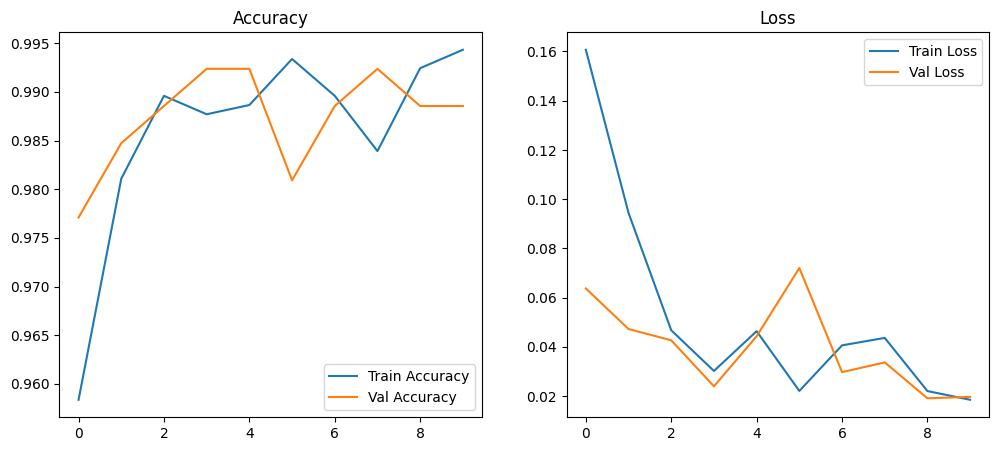

In [ ]:
import matplotlib.pyplot as plt

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Loss')

    plt.show()

# Gọi sau mỗi phase training
plot_training(history)
plot_training(history_finetune)


## 1. Hàng trên – Trước khi fine-tune
**1.1 Accuracy:**
Train Accuracy tăng nhanh lên gần 99%.

Validation Accuracy giữ ổn định quanh 98–99%, nhưng hơi thấp hơn Train Accuracy về cuối.
Mô hình học tốt nhưng có thể hơi overfitting nhẹ vì không cải thiện thêm ở tập validation.

**1.2 Loss:**
Cả Train Loss và Val Loss đều giảm mạnh.

Tuy nhiên, Val Loss bắt đầu tăng nhẹ ở cuối → dấu hiệu overfitting.

## 2. Hàng dưới – Sau khi fine-tune
**2.1 Accuracy:**
Train Accuracy duy trì rất cao (gần 99.5%).

Validation Accuracy cải thiện nhẹ và ổn định hơn so với trước.
Kết luận: Fine-tune giúp mô hình tổng quát hóa tốt hơn, đặc biệt với validation data.

**2.2 Loss:**
Loss thấp hơn rõ rệt so với lúc chưa fine-tune.

Train và Val Loss gần nhau hơn → Mô hình học sâu hơn và cân bằng hơn.



# Kiến trúc model

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/model_hocSau/27042025besst_modelhihi.keras')

In [ ]:
from tensorflow.keras.utils import plot_model

In [ ]:
model.layers

[<InputLayer name=input_layer_3, built=True>,
 <Functional name=efficientnetv2-l, built=True>,
 <Dense name=dense_3, built=True>,
 <BatchNormalization name=batch_normalization_2, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_4, built=True>,
 <BatchNormalization name=batch_normalization_3, built=True>,
 <Dropout name=dropout_3, built=True>,
 <Dense name=dense_5, built=True>]

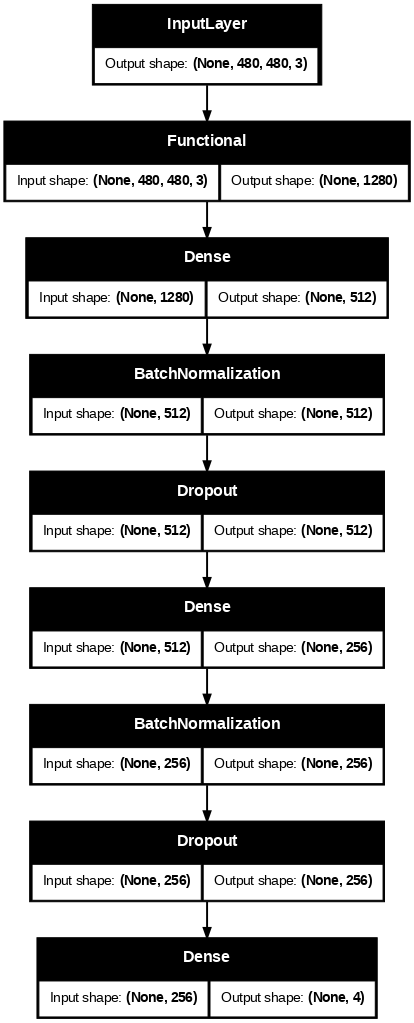

In [ ]:
plot_model(model, show_shapes=True, dpi=70)


In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 480, 480, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-l (Functional)   │ (None, 1280)           │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,851,694 (1002.70 MB)

 Trainable params: 72,156,772 (275.26 MB)

 Non-trainable params: 46,381,376 (176.93 MB)

 Optimizer params: 144,313,546 (550.51 MB)

In [ ]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step - accuracy: 0.9862 - loss: 0.0308 - precision_2: 0.9862 - recall_2: 0.9862
Test Loss: 0.0221
Test Accuracy: 0.9900
Test Precision: 0.9900
Test Recall: 0.9900


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image


In [ ]:

img_path = '/content/drive/MyDrive/test/pigs/Lon_10.jpg'


img = image.load_img(img_path, target_size=(480, 480))


img_array = image.img_to_array(img)


img_array = np.expand_dims(img_array, axis=0)

img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)


In [ ]:
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions)

class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

print("Predicted probabilities:", predictions)
print("Predicted class:", class_names[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Predicted probabilities: [[3.5987565e-08 1.1790897e-06 1.4400423e-07 9.9999857e-01]]
Predicted class: pigs


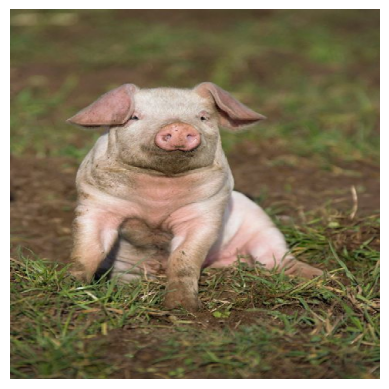

In [ ]:
import matplotlib.pyplot as plt

# Hiển thị ảnh
plt.imshow(img)
plt.axis('off')  # Tắt các trục để chỉ hiển thị ảnh
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 63s 6s/step


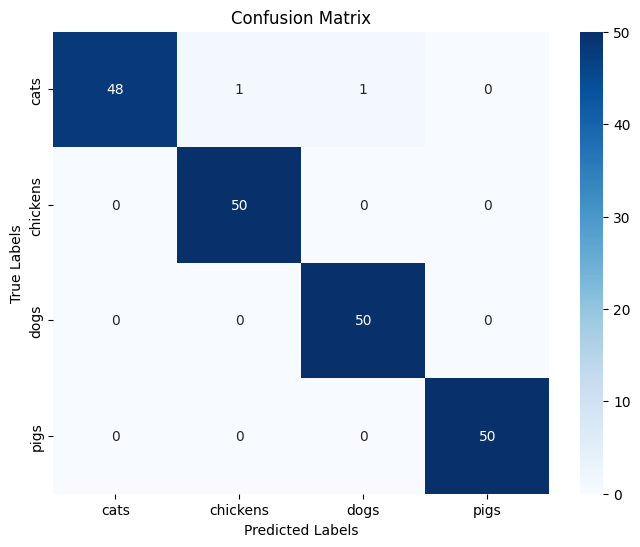

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Lấy true labels và predicted labels từ test_generator
true_labels = test_generator.classes  # Lấy labels thật từ test_generator
predictions = model.predict(test_generator)  # Dự đoán từ model

# Chuyển predictions thành class labels
predicted_labels = np.argmax(predictions, axis=1)

# Tính confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Hiển thị confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
true_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3], dtype=int32)

In [ ]:
model.save('27042025besst_modelhihi.keras')